## Self Attention Demos (Toy Setting for Understanding)

### Demo 1 Rank Analysis Before and After Softmax for a Self Attention Model.

In [1]:
# synthetic attentions with weights init with kaiming normal
import torch
import numpy as np
import torch.nn.functional as F

# -------------------------
# utils
# -------------------------
def approx_rank_90pct_energy(A: torch.Tensor, tau: float = 0.90) -> int:
    """
    A: [L, L] matrix (float32 recommended)
    Returns smallest r such that sum_{i<=r} s_i^2 / sum_i s_i^2 >= tau
    """
    A = A.to(torch.float32)
    s = torch.linalg.svdvals(A)  # singular values, shape [L]
    energy = s**2
    total = energy.sum()
    if total == 0:
        return 0
    cum = torch.cumsum(energy / total, dim=0)
    r = torch.searchsorted(cum, tau).item() + 1
    return r

# -------------------------
# Set seed for reproducibility
# -------------------------
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Define the parameters
seq_length = 1024
hidden_size = 2048
num_attention_heads = 32
head_dim = hidden_size // num_attention_heads
batch_size = 8  # Example batch size

# Create synthetic input data
X = torch.randn(batch_size, seq_length, hidden_size)

# Create synthetic weights for each head using Kaiming He initialization
W_Q = torch.empty(num_attention_heads, hidden_size, head_dim)
W_K = torch.empty(num_attention_heads, hidden_size, head_dim)
W_V = torch.empty(num_attention_heads, hidden_size, head_dim)

torch.nn.init.kaiming_normal_(W_Q, nonlinearity='relu')
torch.nn.init.kaiming_normal_(W_K, nonlinearity='relu')
torch.nn.init.kaiming_normal_(W_V, nonlinearity='relu')

# Initialize tensors for Q, K, V
Q = torch.zeros(batch_size, num_attention_heads, seq_length, head_dim)
K = torch.zeros(batch_size, num_attention_heads, seq_length, head_dim)
V = torch.zeros(batch_size, num_attention_heads, seq_length, head_dim)

# Compute Q, K, V for each head
for i in range(num_attention_heads):
    Q[:, i, :, :] = torch.matmul(X, W_Q[i])
    K[:, i, :, :] = torch.matmul(X, W_K[i])
    V[:, i, :, :] = torch.matmul(X, W_V[i])

# -------------------------
# Rank before + after softmax (per head)
# (streamed per head to avoid storing [B,H,L,L] all at once)
# -------------------------
scale = head_dim ** 0.5

pre_ranks = []
post_ranks = []

with torch.no_grad():
    for i in range(num_attention_heads):
        # logits: [B, L, L]
        logits = torch.matmul(Q[:, i, :, :], K[:, i, :, :].transpose(-2, -1)) / scale

        # mean over batch -> [L, L]
        logits_mean = logits.mean(dim=0)

        # post-softmax: [B, L, L] then mean -> [L, L]
        probs = F.softmax(logits, dim=-1)
        probs_mean = probs.mean(dim=0)

        pre_rank = approx_rank_90pct_energy(logits_mean, tau=0.90)
        post_rank = approx_rank_90pct_energy(probs_mean, tau=0.90)

        pre_ranks.append(pre_rank)
        post_ranks.append(post_rank)

        print(f"Head {i+1:02d}: rank(pre-softmax)={pre_rank:4d} | rank(post-softmax)={post_rank:4d}")

print(f"\nMax rank (pre-softmax):  {max(pre_ranks)}")
print(f"Max rank (post-softmax): {max(post_ranks)}")


Head 01: rank(pre-softmax)= 275 | rank(post-softmax)=   1
Head 02: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 03: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 04: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 05: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 06: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 07: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 08: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 09: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 10: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 11: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 12: rank(pre-softmax)= 275 | rank(post-softmax)=   1
Head 13: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 14: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 15: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 16: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 17: rank(pre-softmax)= 274 | rank(post-softmax)=   1
Head 18: rank(

### Demo 2 Rank Evolution of a Self Attention During Training.

Starting training with rank tracking...
Step     0 | Avg Rank:  45.25
Step   500 | Avg Rank:   1.00
Training complete! Creating rank evolution animation...

✓ Saved: figs/rank_evolution.gif

Animation created successfully!

Final Statistics:
  Initial Average Rank: 45.25
  Final Average Rank: 1.00
  Rank Reduction: 97.8%

Displaying animation:


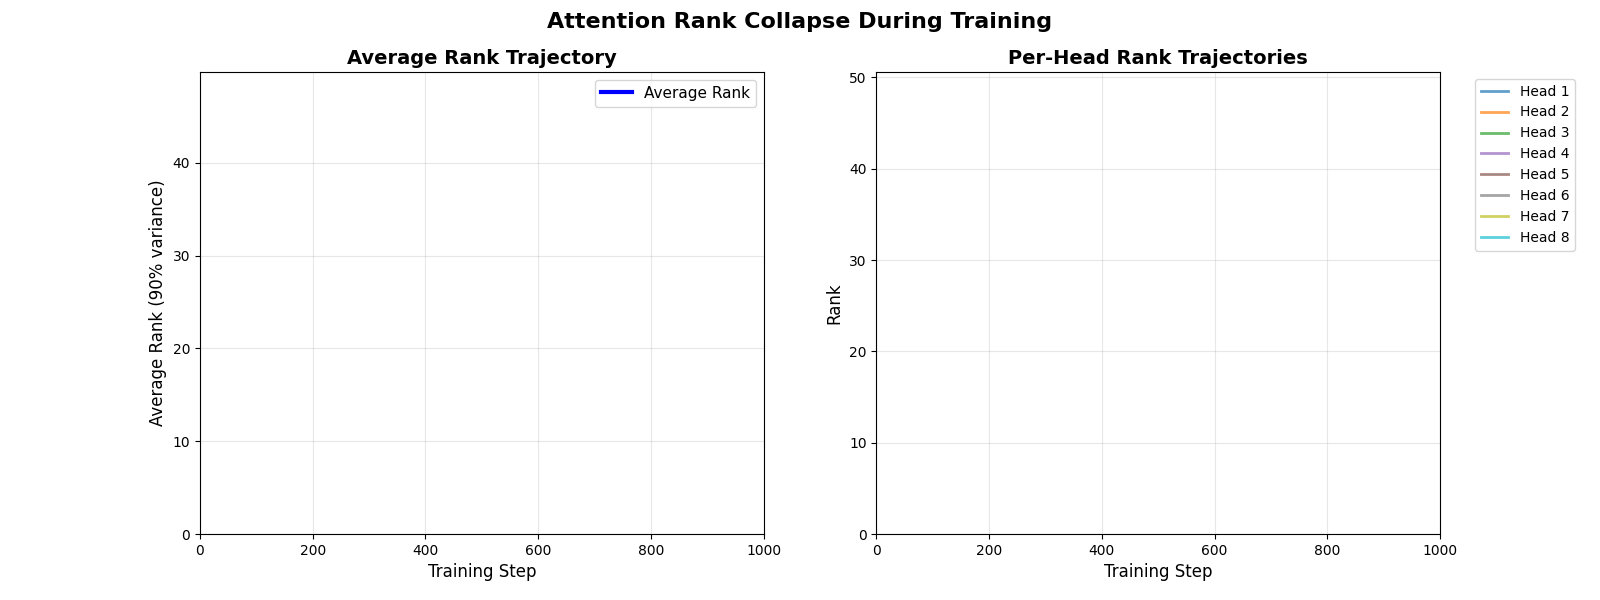

In [3]:
# Attention Collapse Demonstration - Rank Evolution Only
# Shows how attention rank decreases during training

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os
from IPython.display import Image, display

# Create output directory
os.makedirs('figs', exist_ok=True)

# Set seed for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# Define parameters
seq_length = 128
hidden_size = 512
num_attention_heads = 8
head_dim = hidden_size // num_attention_heads
batch_size = 16
num_training_steps = 1000
checkpoint_interval = 50  # More frequent for smoother animation


class SimpleAttention(nn.Module):
    def __init__(self, hidden_size, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        self.hidden_size = hidden_size

        self.W_Q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_K = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_V = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_O = nn.Linear(hidden_size, hidden_size, bias=False)

        nn.init.kaiming_normal_(self.W_Q.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.W_K.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.W_V.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.W_O.weight, nonlinearity='relu')

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)

        attn_output = torch.matmul(attn_weights, V)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.hidden_size)
        output = self.W_O(attn_output)

        return output, attn_weights


def compute_attention_rank(attn_weights, variance_threshold=0.90):
    batch_size, num_heads, seq_len, _ = attn_weights.shape
    avg_attn = attn_weights.mean(dim=0)

    ranks = []
    for i in range(num_heads):
        att_matrix = avg_attn[i].detach().cpu().to(torch.float32)
        singular_values = torch.linalg.svdvals(att_matrix)
        total_variance = torch.sum(singular_values ** 2)
        explained_variances = (singular_values ** 2) / total_variance
        cumulative_explained_variance = torch.cumsum(explained_variances, dim=0)
        rank = torch.searchsorted(cumulative_explained_variance, variance_threshold) + 1
        ranks.append(rank.item())

    return ranks


# Initialize model and optimizer
model = SimpleAttention(hidden_size, num_attention_heads)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Storage for metrics
rank_history = {f'head_{i}': [] for i in range(num_attention_heads)}
avg_rank_history = []
checkpoint_steps = []

# Fixed validation batch for consistent visualization
torch.manual_seed(seed)
X_val_fixed = torch.randn(batch_size, seq_length, hidden_size)

print("Starting training with rank tracking...")
print("=" * 70)

# Training loop
for step in range(num_training_steps):
    X = torch.randn(batch_size, seq_length, hidden_size)
    output, attn_weights = model(X)
    target = torch.randn_like(output)
    loss = F.mse_loss(output, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Capture metrics at checkpoints
    if step % checkpoint_interval == 0 or step == num_training_steps - 1:
        with torch.no_grad():
            _, attn_val = model(X_val_fixed)

            # Compute ranks
            ranks = compute_attention_rank(attn_val)
            avg_rank = np.mean(ranks)

            # Store history
            for i, rank in enumerate(ranks):
                rank_history[f'head_{i}'].append(rank)
            avg_rank_history.append(avg_rank)

            checkpoint_steps.append(step)

            if step % (checkpoint_interval * 10) == 0:
                print(f"Step {step:5d} | Avg Rank: {avg_rank:6.2f}")

print("=" * 70)
print("Training complete! Creating rank evolution animation...")
print()

# ============================================================================
# ANIMATION: Rank Evolution
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Attention Rank Collapse During Training', fontsize=16, fontweight='bold')

# Setup plot 1: Average rank over time
line_avg, = ax1.plot([], [], 'b-', linewidth=3, label='Average Rank')
ax1.set_xlim(0, num_training_steps)
ax1.set_ylim(0, max(avg_rank_history) * 1.1)
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Average Rank (90% variance)', fontsize=12)
ax1.set_title('Average Rank Trajectory', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Setup plot 2: Per-head ranks
lines_heads = []
colors = plt.cm.tab10(np.linspace(0, 1, num_attention_heads))
for i in range(num_attention_heads):
    line, = ax2.plot([], [], linewidth=2, alpha=0.7, label=f'Head {i + 1}', color=colors[i])
    lines_heads.append(line)

ax2.set_xlim(0, num_training_steps)
max_rank = max([max(rank_history[f'head_{i}']) for i in range(num_attention_heads)])
ax2.set_ylim(0, max_rank * 1.1)
ax2.set_xlabel('Training Step', fontsize=12)
ax2.set_ylabel('Rank', fontsize=12)
ax2.set_title('Per-Head Rank Trajectories', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Add step counter and stats
info_text = fig.text(0.5, 0.02, '', ha='center', fontsize=12, fontweight='bold')


def animate_rank(frame):
    current_steps = checkpoint_steps[:frame + 1]
    current_avg_ranks = avg_rank_history[:frame + 1]

    # Update average rank line
    line_avg.set_data(current_steps, current_avg_ranks)

    # Update per-head lines
    for i in range(num_attention_heads):
        current_head_ranks = rank_history[f'head_{i}'][:frame + 1]
        lines_heads[i].set_data(current_steps, current_head_ranks)

    # Update info text
    step = checkpoint_steps[frame]
    avg_rank = avg_rank_history[frame]
    initial_rank = avg_rank_history[0]
    reduction_pct = 100 * (initial_rank - avg_rank) / initial_rank
    info_text.set_text(
        f'Step: {step:,} | Average Rank: {avg_rank:.1f} | '
        f'Reduction: {reduction_pct:.1f}% from initial'
    )

    return [line_avg] + lines_heads + [info_text]


anim = FuncAnimation(fig, animate_rank, frames=len(checkpoint_steps),
                     interval=100, blit=True, repeat=True)

writer = PillowWriter(fps=10)
anim.save('figs/rank_evolution.gif', writer=writer, dpi=100)
plt.close()

print("✓ Saved: figs/rank_evolution.gif")
print()
print("=" * 70)
print("Animation created successfully!")
print("=" * 70)
print()
print("Final Statistics:")
print(f"  Initial Average Rank: {avg_rank_history[0]:.2f}")
print(f"  Final Average Rank: {avg_rank_history[-1]:.2f}")
print(f"  Rank Reduction: {100 * (avg_rank_history[0] - avg_rank_history[-1]) / avg_rank_history[0]:.1f}%")
print()

# Display the GIF in Colab
print("Displaying animation:")
display(Image(filename='figs/rank_evolution.gif'))